En este cuaderno, desarrollaremos varios modelos para entrenarlos y evaluarlos. En la memoria, se explica el proceso con mayor detalle

In [1]:
import pandas as pd

# Empezamos importando los datos
df_total = pd.read_parquet("../data/billetes_procesados.parquet")

df_total[['Usuario','Fecha', 'Origen', 'Destino', 'Nombre de producto','Fecha compra']].head()

,Usuario,Fecha,Origen,Destino,Nombre de producto,Fecha compra
0,usuario_1,2024-01-31,Valencia-Joaquín Sorolla,Madrid-Chamartín,Inicial,2024-01-18
1,usuario_2,2024-01-28,Barcelona-Sants,Madrid-Puerta de Atocha,Infinita Bistró,2024-01-05
2,usuario_2,2024-01-20,Madrid-Puerta de Atocha,Barcelona-Sants,Infinita Bistró,2024-01-11
3,usuario_2,2024-03-23,Madrid-Puerta de Atocha,Barcelona-Sants,Inicial,2024-02-13
4,usuario_2,2024-02-21,Madrid-Puerta de Atocha,Barcelona-Sants,Inicial,2024-02-14


In [2]:
# Definimos las variables (rutas y clases)
combinaciones = [['Madrid-Chamartín', 'Valencia-Joaquín Sorolla'],
 ['Barcelona-Sants', 'Zaragoza-Delicias'],
 ['Barcelona-Sants', 'Tarragona-Camp de Tarragona'],
 ['Tarragona-Camp de Tarragona', 'Barcelona-Sants'],
 ['Sevilla-Santa Justa', 'Tarragona-Camp de Tarragona'],
 ['Tarragona-Camp de Tarragona', 'Sevilla-Santa Justa'],
 ['Madrid-Puerta de Atocha', 'Sevilla-Santa Justa'],
 ['Málaga-María Zambrano', 'Madrid-Puerta de Atocha'],
 ['Barcelona-Sants', 'Madrid-Puerta de Atocha'],
 ['Sevilla-Santa Justa', 'Madrid-Puerta de Atocha'],
 ['Madrid-Puerta de Atocha', 'Málaga-María Zambrano'],
 ['Valencia-Joaquín Sorolla', 'Madrid-Chamartín'],
 ['Madrid-Puerta de Atocha', 'Barcelona-Sants'],
 ['Madrid-Chamartín', 'Albacete-Los Llanos'],
 ['Madrid-Puerta de Atocha', 'Zaragoza-Delicias'],
 ['Málaga-María Zambrano', 'Barcelona-Sants'],
 ['Córdoba', 'Madrid-Puerta de Atocha'],
 ['Madrid-Puerta de Atocha', 'Córdoba'],
 ['Zaragoza-Delicias', 'Madrid-Puerta de Atocha'],
 ['Córdoba', 'Barcelona-Sants'],
 ['Zaragoza-Delicias', 'Barcelona-Sants'],
 ['Madrid-Chamartín', 'Alicante-Terminal'],
 ['Alicante-Terminal', 'Madrid-Chamartín'],
 ['Barcelona-Sants', 'Málaga-María Zambrano'],
 ['Sevilla-Santa Justa', 'Córdoba'],
 ['Córdoba', 'Sevilla-Santa Justa'],
 ['Madrid-Chamartín', 'Cuenca-Fernando Zóbel'],
 ['Zaragoza-Delicias', 'Málaga-María Zambrano'],
 ['Barcelona-Sants', 'Córdoba'],
 ['Zaragoza-Delicias', 'Sevilla-Santa Justa'],
 ['Barcelona-Sants', 'Sevilla-Santa Justa'],
 ['Sevilla-Santa Justa', 'Barcelona-Sants'],
 ['Alicante-Terminal', 'Cuenca-Fernando Zóbel'],
 ['Málaga-María Zambrano', 'Córdoba'],
 ['Málaga-María Zambrano', 'Zaragoza-Delicias'],
 ['Sevilla-Santa Justa', 'Zaragoza-Delicias'],
 ['Cuenca-Fernando Zóbel', 'Madrid-Chamartín'],
 ['Cuenca-Fernando Zóbel', 'Valencia-Joaquín Sorolla'],
 ['Cuenca-Fernando Zóbel', 'Albacete-Los Llanos'],
 ['Albacete-Los Llanos', 'Alicante-Terminal'],
 ['Tarragona-Camp de Tarragona', 'Madrid-Puerta de Atocha'],
 ['Tarragona-Camp de Tarragona', 'Córdoba'],
 ['Córdoba', 'Tarragona-Camp de Tarragona'],
 ['Tarragona-Camp de Tarragona', 'Zaragoza-Delicias'],
 ['Zaragoza-Delicias', 'Tarragona-Camp de Tarragona'],
 ['Córdoba', 'Málaga-María Zambrano'],
 ['Córdoba', 'Zaragoza-Delicias'],
 ['Albacete-Los Llanos', 'Madrid-Chamartín'],
 ['Madrid-Puerta de Atocha', 'Tarragona-Camp de Tarragona'],
 ['Alicante-Terminal', 'Albacete-Los Llanos'],
 ['Albacete-Los Llanos','Cuenca-Fernando Zóbel'],
 ['Valencia-Joaquín Sorolla', 'Cuenca-Fernando Zóbel'],
 ['Zaragoza-Delicias', 'Córdoba'],
 ['Cuenca-Fernando Zóbel', 'Alicante-Terminal']]

clases_billetes = df_total["Nombre de producto"].dropna().drop_duplicates().tolist()

dict_rutas = {tuple(x): i for i, x in enumerate(combinaciones)}
dict_clases = {c: i for i, c in enumerate(clases_billetes)}

n_rutas = len(combinaciones)
n_clases = len(clases_billetes)

n_rutas, n_clases


(54, 10)

# Partición común a todos los modelos


Empezaremos formando una partición global para asegurar la igualdad de condiciones en todos los modelos. Esta partición se hace por usuario.

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

TEST_SIZE = 0.25

def build_shared_user_split(df_source, combinaciones, clases_billetes, test_size, seed):
    """Split por usuario compartido entre modelos."""
    rutas_objetivo = pd.MultiIndex.from_tuples(
        [tuple(x) for x in combinaciones],
        names=["Origen", "Destino"],
    )
    clases_objetivo = pd.Index(clases_billetes, name="Nombre de producto")

    # Matriz total por usuario (rutas + clases)
    df_od = (
        df_source.groupby(["Usuario", "Origen", "Destino"])
        .size()
        .reset_index(name="Count_OD")
    )
    df_od_pivot = (
        df_od.pivot(index="Usuario", columns=["Origen", "Destino"], values="Count_OD")
        .fillna(0)
        .reindex(columns=rutas_objetivo, fill_value=0)
    )

    df_clase = (
        df_source.groupby(["Usuario", "Nombre de producto"])
        .size()
        .reset_index(name="Count_Clase")
    )
    df_clase_pivot = (
        df_clase.pivot(index="Usuario", columns="Nombre de producto", values="Count_Clase")
        .fillna(0)
        .reindex(columns=clases_objetivo, fill_value=0)
    )

    df_total_user = pd.concat([df_od_pivot, df_clase_pivot], axis=1)

    # Ultimo billete por usuario (mismo criterio: Fecha + Hora)
    df_tmp = df_source.copy()
    df_tmp["Fecha"] = pd.to_datetime(df_tmp["Fecha"], errors="coerce")
    df_tmp["Hora"] = df_tmp["Hora"].astype(str)

    hora_dt = pd.to_datetime(df_tmp["Hora"], format="%H:%M:%S", errors="coerce")
    df_tmp["_hora_sort"] = hora_dt.dt.time
    df_tmp["_hora_sort"] = df_tmp["_hora_sort"].fillna(pd.to_datetime("00:00:00").time())

    df_ultimo = (
        df_tmp.sort_values(["Usuario", "Fecha", "_hora_sort"])
        .drop_duplicates("Usuario", keep="last")
    )

    df_ultimo_od = (
        df_ultimo.groupby(["Usuario", "Origen", "Destino"])
        .size()
        .reset_index(name="Count_OD")
    )
    df_ultimo_od_pivot = (
        df_ultimo_od.pivot(index="Usuario", columns=["Origen", "Destino"], values="Count_OD")
        .fillna(0)
        .reindex(columns=rutas_objetivo, fill_value=0)
    )

    df_ultimo_clase = (
        df_ultimo.groupby(["Usuario", "Nombre de producto"])
        .size()
        .reset_index(name="Count_Clase")
    )
    df_ultimo_clase_pivot = (
        df_ultimo_clase.pivot(index="Usuario", columns="Nombre de producto", values="Count_Clase")
        .fillna(0)
        .reindex(columns=clases_objetivo, fill_value=0)
    )

    df_ultimo_user = pd.concat([df_ultimo_od_pivot, df_ultimo_clase_pivot], axis=1)

    usuarios_comunes = df_total_user.index.intersection(df_ultimo_user.index)
    df_total_user = df_total_user.loc[usuarios_comunes]
    df_ultimo_user = df_ultimo_user.loc[usuarios_comunes]
    df_ultimo_user = df_ultimo_user[df_total_user.columns]

    x_hist = df_total_user.to_numpy().astype(int) - df_ultimo_user.to_numpy().astype(int)
    usuarios = df_total_user.index.to_numpy()

    # Quitamos usuarios con historial vacio (equivalente a un único billete)
    idx_drop = [i for i in range(len(x_hist)) if np.all(x_hist[i] == 0)]
    if len(idx_drop) > 0:
        usuarios = np.delete(usuarios, idx_drop, axis=0)

    u_train, u_test = train_test_split(
        usuarios,
        test_size=test_size,
        random_state=seed,
    )

    return set(u_train.tolist()), set(u_test.tolist())


seed_split = SEED if "SEED" in globals() else 42
test_size_split = TEST_SIZE if "TEST_SIZE" in globals() else 0.25

users_train, users_test = build_shared_user_split(
    df_total,
    combinaciones,
    clases_billetes,
    test_size=test_size_split,
    seed=seed_split,
)

print("Particion comun creada")
print("Usuarios train:", len(users_train), "| Usuarios test:", len(users_test))


Particion comun creada
Usuarios train: 14226 | Usuarios test: 4742


# Baselines

Para continuar, se pasa a definir las baselines basadas en estrategias simples de recomendación, que suponen el mínimo nivel de acierto que los modelos deben superar.

In [4]:
# Baselines (rutas + tipo de producto)

import numpy as np
import pandas as pd


def topk_metrics_from_scores(y_true, score_rows, ks=(1, 2, 3)):
    """
    Calcula métricas Top-k a partir de puntuaciones.
    """
    y_true = np.asarray(y_true, dtype=np.int64)
    score_rows = np.asarray(score_rows)
    order = np.argsort(-score_rows, axis=1)

    out = {}
    for k in ks:
        topk = order[:, :k]
        out[k] = float((topk == y_true[:, None]).any(axis=1).mean())
    return out


def counts_to_scores(counts_dict, n_items):
    """
    Convierte un diccionario de conteos {id_clase: conteo} en un vector de scores
    de longitud n_items, donde cada posición corresponde a una clase/ítem.
    """
    scores = np.zeros(n_items, dtype=np.float64)

    if isinstance(counts_dict, dict):
        for idx, value in counts_dict.items():
            idx = int(idx)
            if 0 <= idx < n_items:
                scores[idx] = float(value)

    return scores


# Preparacion del dataset
df_baselines = df_total.copy()
df_baselines["Fecha"] = pd.to_datetime(df_baselines["Fecha"], errors="coerce")
df_baselines["Hora"] = df_baselines["Hora"].astype(str)

hora_dt = pd.to_datetime(df_baselines["Hora"], format="%H:%M:%S", errors="coerce")
df_baselines["_hora_sort"] = hora_dt.dt.time
df_baselines["_hora_sort"] = df_baselines["_hora_sort"].fillna(pd.to_datetime("00:00:00").time())

df_baselines["_ruta_key"] = list(zip(df_baselines["Origen"], df_baselines["Destino"]))
df_baselines = df_baselines[df_baselines["_ruta_key"].isin(dict_rutas)].copy()
df_baselines = df_baselines[df_baselines["Nombre de producto"].isin(dict_clases)].copy()

df_baselines["ruta_id"] = df_baselines["_ruta_key"].map(dict_rutas).astype(int)
df_baselines["clase_id"] = df_baselines["Nombre de producto"].map(dict_clases).astype(int)

df_baselines = df_baselines.sort_values(["Usuario", "Fecha", "_hora_sort"]).reset_index(drop=True)

rows = []
for usuario, grp in df_baselines.groupby("Usuario", sort=False):
    if len(grp) < 2:
        continue

    hist = grp.iloc[:-1]
    target = grp.iloc[-1]
    last_hist = hist.iloc[-1]

    vuelta_id = dict_rutas.get((last_hist["Destino"], last_hist["Origen"]), np.nan)

    rows.append(
        {
            "Usuario": usuario,
            "y_ruta": int(target["ruta_id"]),
            "y_clase": int(target["clase_id"]),
            "last_hist_ruta_id": int(last_hist["ruta_id"]),
            "vuelta_ruta_id": vuelta_id,
            "hist_ruta_counts": hist["ruta_id"].value_counts().to_dict(),
            "hist_clase_counts": hist["clase_id"].value_counts().to_dict(),
        }
    )

df_user_eval = pd.DataFrame(rows)



# Split train/validate: usamos la particion comun definida al inicio
users_train_bl = set(users_train)
users_test_bl = set(users_test)

# Aseguramos que train/test solo contienen usuarios con ejemplo válido en esta evaluación
users_available = set(df_user_eval["Usuario"].tolist())
users_train_bl = users_train_bl.intersection(users_available)
users_test_bl = users_test_bl.intersection(users_available)

df_train_users = df_user_eval[df_user_eval["Usuario"].isin(users_train_bl)].copy()
df_test_users = df_user_eval[df_user_eval["Usuario"].isin(users_test_bl)].copy()

df_train_tickets = df_baselines[df_baselines["Usuario"].isin(users_train_bl)].copy()

print("Usuarios train (baselines):", df_train_users["Usuario"].nunique())
print("Usuarios test (baselines):", df_test_users["Usuario"].nunique())


# Popularidades globales (con train)
global_route_scores = np.zeros(n_rutas, dtype=np.float64)
route_counts_global = df_train_tickets["ruta_id"].value_counts()
for rid, cnt in route_counts_global.items():
    global_route_scores[int(rid)] = float(cnt)

global_class_scores = np.zeros(n_clases, dtype=np.float64)
class_counts_global = df_train_tickets["clase_id"].value_counts()
for cid, cnt in class_counts_global.items():
    global_class_scores[int(cid)] = float(cnt)

if global_route_scores.sum() == 0:
    global_route_scores[:] = 1.0
if global_class_scores.sum() == 0:
    global_class_scores[:] = 1.0


# Baselines de ruta

# Ruta global más frecuente (Top-k)
scores_ruta_global = np.vstack([global_route_scores for _ in range(len(df_test_users))])

# Ultima ruta (ida), recomendamos la última ruta
scores_ruta_ultima_ida = []
for row in df_test_users.itertuples(index=False):
    s = 1e-6 * global_route_scores.copy()
    s[int(row.last_hist_ruta_id)] += 1.0
    scores_ruta_ultima_ida.append(s)
scores_ruta_ultima_ida = np.vstack(scores_ruta_ultima_ida)

# Ultima ruta (vuelta), recomendamos la vuelta de la  última ruta
scores_ruta_ultima_vuelta = []
for row in df_test_users.itertuples(index=False):
    s = 1e-6 * global_route_scores.copy()
    s[int(row.vuelta_ruta_id)] += 1.0
    scores_ruta_ultima_vuelta.append(s)
scores_ruta_ultima_vuelta = np.vstack(scores_ruta_ultima_vuelta)

# Ruta más frecuente personal de cada usuario
scores_ruta_freq_personal = []
for row in df_test_users.itertuples(index=False):
    s = counts_to_scores(
        row.hist_ruta_counts,
        n_rutas,
    )
    scores_ruta_freq_personal.append(s)
scores_ruta_freq_personal = np.vstack(scores_ruta_freq_personal)


# Baselines de tipo de producto

# Tipo global más frecuente
scores_clase_global = np.vstack([global_class_scores for _ in range(len(df_test_users))])

# Tipo más frecuente personal
scores_clase_freq_personal = []
for row in df_test_users.itertuples(index=False):
    s = counts_to_scores(
        row.hist_clase_counts,
        n_clases,
    )
    scores_clase_freq_personal.append(s)
scores_clase_freq_personal = np.vstack(scores_clase_freq_personal)


# Evaluacion top-k
y_ruta_bl = df_test_users["y_ruta"].to_numpy(dtype=np.int64)
y_clase_bl = df_test_users["y_clase"].to_numpy(dtype=np.int64)

m_ruta_global = topk_metrics_from_scores(y_ruta_bl, scores_ruta_global, ks=(1, 2, 3))
m_ruta_ultima_ida = topk_metrics_from_scores(y_ruta_bl, scores_ruta_ultima_ida, ks=(1, 2, 3))
m_ruta_ultima_vuelta = topk_metrics_from_scores(y_ruta_bl, scores_ruta_ultima_vuelta, ks=(1, 2, 3))
m_ruta_freq_personal = topk_metrics_from_scores(y_ruta_bl, scores_ruta_freq_personal, ks=(1, 2, 3))

m_clase_global = topk_metrics_from_scores(y_clase_bl, scores_clase_global, ks=(1, 2, 3))
m_clase_freq_personal = topk_metrics_from_scores(y_clase_bl, scores_clase_freq_personal, ks=(1, 2, 3))

# Comparamos resultados
print(f"Baseline Ruta global - Top-1={m_ruta_global[1]:.4f} | Top-2={m_ruta_global[2]:.4f} | Top-3={m_ruta_global[3]:.4f}")
print(f"Baseline Ultima ruta (ida) - Top-1={m_ruta_ultima_ida[1]:.4f} | Top-2={m_ruta_ultima_ida[2]:.4f} | Top-3={m_ruta_ultima_ida[3]:.4f}")
print(f"Baseline Ultima ruta (vuelta) - Top-1={m_ruta_ultima_vuelta[1]:.4f} | Top-2={m_ruta_ultima_vuelta[2]:.4f} | Top-3={m_ruta_ultima_vuelta[3]:.4f}")
print(f"Baseline Ruta frecuente personal - Top-1={m_ruta_freq_personal[1]:.4f} | Top-2={m_ruta_freq_personal[2]:.4f} | Top-3={m_ruta_freq_personal[3]:.4f}")

print(f"Baseline Clase global - Top-1={m_clase_global[1]:.4f} | Top-2={m_clase_global[2]:.4f} | Top-3={m_clase_global[3]:.4f}")
print(f"Baseline Clase frecuente personal - Top-1={m_clase_freq_personal[1]:.4f} | Top-2={m_clase_freq_personal[2]:.4f} | Top-3={m_clase_freq_personal[3]:.4f}")

# Añadimos solo la mejor de cada tipo
baseline_results = {
    #"BL Ruta global": {"ruta": {1: m_ruta_global[1], 2: m_ruta_global[2], 3: m_ruta_global[3]}},
    #"BL Ultima ruta ida": {"ruta": {1: m_ruta_ultima_ida[1], 2: m_ruta_ultima_ida[2], 3: m_ruta_ultima_ida[3]}},
    "BL Ultima ruta vuelta": {"ruta": {1: m_ruta_ultima_vuelta[1], 2: m_ruta_ultima_vuelta[2], 3: m_ruta_ultima_vuelta[3]}},
    #"BL Ruta frecuente personal": {"ruta": {1: m_ruta_freq_personal[1], 2: m_ruta_freq_personal[2], 3: m_ruta_freq_personal[3]}},
    #"BL Clase global": {"clase": {1: m_clase_global[1], 2: m_clase_global[2], 3: m_clase_global[3]}},
    "BL Clase frecuente personal": {"clase": {1: m_clase_freq_personal[1], 2: m_clase_freq_personal[2], 3: m_clase_freq_personal[3]}},
}


Usuarios train (baselines): 14226
Usuarios test (baselines): 4742
Baseline Ruta global - Top-1=0.1875 | Top-2=0.3505 | Top-3=0.4610
Baseline Ultima ruta (ida) - Top-1=0.3518 | Top-2=0.5603 | Top-3=0.5791
Baseline Ultima ruta (vuelta) - Top-1=0.5129 | Top-2=0.6561 | Top-3=0.6748
Baseline Ruta frecuente personal - Top-1=0.3475 | Top-2=0.5038 | Top-3=0.5082
Baseline Clase global - Top-1=0.6841 | Top-2=0.8863 | Top-3=0.9509
Baseline Clase frecuente personal - Top-1=0.7921 | Top-2=0.8939 | Top-3=0.9633


# Cold start

Antes de entrar en los modelos, tratamos el problema del cold start. Es decir, la recomendación que hacemos a usuarios nuevos.
Para simular usuarios nuevos, tomamos los usuarios que tienen un único billete y será el objetivo a predecir.

In [5]:
# Cold start (usuarios con un solo viaje)

# Identificamos a los usuarios (1 único billete)
tickets_por_usuario = df_baselines.groupby("Usuario").size()
users_cold = tickets_por_usuario[tickets_por_usuario == 1].index.tolist()

df_cold = df_baselines[df_baselines["Usuario"].isin(users_cold)].copy()

# 1 fila por usuario
assert df_cold.groupby("Usuario").size().max() == 1

seed_cs = SEED if "SEED" in globals() else 42
test_size_cs = TEST_SIZE if "TEST_SIZE" in globals() else 0.25

u_train, u_val = train_test_split(
    users_cold,
    test_size=test_size_cs,
    random_state=seed_cs,
)

users_train_cs = set(u_train)
users_val_cs = set(u_val)

df_train_cs = df_cold[df_cold["Usuario"].isin(users_train_cs)].copy()
df_val_cs = df_cold[df_cold["Usuario"].isin(users_val_cs)].copy()


print("Usuarios cold-start totales:", len(users_cold))
print("Usuarios cold-start train:", len(users_train_cs))
print("Usuarios cold-start validate:", len(users_val_cs))


# Top-3 populares en train
route_counts_train = df_train_cs["ruta_id"].value_counts()
class_counts_train = df_train_cs["clase_id"].value_counts()

top3_rutas = route_counts_train.head(3).index.tolist()
top3_clases = class_counts_train.head(3).index.tolist()

print("Top-3 rutas (train):")
for i, rid in enumerate(top3_rutas, start=1):
    o, d = combinaciones[rid]
    print(f"  {i}. {o} -> {d}")

print("Top-3 clases (train):")
for i, cid in enumerate(top3_clases, start=1):
    print(f"  {i}. {clases_billetes[cid]}")


# Evaluamos en validate (mismo top-3 para todos los usuarios)
score_ruta = np.zeros(n_rutas, dtype=np.float64)
score_clase = np.zeros(n_clases, dtype=np.float64)

# Ranking por popularidad
for rank, rid in enumerate(top3_rutas):
    score_ruta[int(rid)] = 3 - rank

for rank, cid in enumerate(top3_clases):
    score_clase[int(cid)] = 3 - rank

scores_ruta_val = np.vstack([score_ruta for _ in range(len(df_val_cs))])
scores_clase_val = np.vstack([score_clase for _ in range(len(df_val_cs))])

y_ruta_val_cs = df_val_cs["ruta_id"].to_numpy(dtype=np.int64)
y_clase_val_cs = df_val_cs["clase_id"].to_numpy(dtype=np.int64)

m_ruta_cs = topk_metrics_from_scores(y_ruta_val_cs, scores_ruta_val, ks=(1, 2, 3))
m_clase_cs = topk_metrics_from_scores(y_clase_val_cs, scores_clase_val, ks=(1, 2, 3))

print(f"Cold start (1 viaje) Ruta - Top-1={m_ruta_cs[1]:.4f} | Top-2={m_ruta_cs[2]:.4f} | Top-3={m_ruta_cs[3]:.4f}")
print(f"Cold start (1 viaje) Clase - Top-1={m_clase_cs[1]:.4f} | Top-2={m_clase_cs[2]:.4f} | Top-3={m_clase_cs[3]:.4f}")

Usuarios cold-start totales: 43475
Usuarios cold-start train: 32606
Usuarios cold-start validate: 10869
Top-3 rutas (train):
  1. Madrid-Puerta de Atocha -> Barcelona-Sants
  2. Barcelona-Sants -> Madrid-Puerta de Atocha
  3. Madrid-Chamartín -> Valencia-Joaquín Sorolla
Top-3 clases (train):
  1. Inicial
  2. Singular Only You
  3. Infinita Bistró
Cold start (1 viaje) Ruta - Top-1=0.1620 | Top-2=0.3092 | Top-3=0.4245
Cold start (1 viaje) Clase - Top-1=0.6961 | Top-2=0.8903 | Top-3=0.9455


# Red neuronal densa

Como primer modelo, planteamos dos redes neuronales densas. Cada una para predecir cada variable y basándonos en la información de "contar" cuantas veces se repite cada ruta y clase.

In [6]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TEST_SIZE = 0.25

In [7]:
df = df_total.copy()

# Variables (rutas + clases)
variables = combinaciones + clases_billetes

len(combinaciones), len(clases_billetes)


(54, 10)

Empezamos calculando la matriz de conteos.

In [8]:
# Matriz total por usuario: rutas + clases
df_billetes = df.copy()

# Columnas objetivo
rutas_objetivo = pd.MultiIndex.from_tuples(
    [tuple(x) for x in combinaciones],
    names=["Origen", "Destino"]
)

clases_objetivo = pd.Index(clases_billetes, name="Nombre de producto")

# Conteos por ruta
df_od = (
    df_billetes.groupby(["Usuario", "Origen", "Destino"])
    .size()
    .reset_index(name="Count_OD")
)

df_od_pivot = (
    df_od.pivot(index="Usuario", columns=["Origen", "Destino"], values="Count_OD")
    .fillna(0)
)

# Aseguramos todas las rutas
df_od_pivot = df_od_pivot.reindex(columns=rutas_objetivo, fill_value=0)

# Conteos por clase
df_clase = (
    df_billetes.groupby(["Usuario", "Nombre de producto"])
    .size()
    .reset_index(name="Count_Clase")
)

df_clase_pivot = (
    df_clase.pivot(index="Usuario", columns="Nombre de producto", values="Count_Clase")
    .fillna(0)
)

# Aseguramos todas las clases
df_clase_pivot = df_clase_pivot.reindex(columns=clases_objetivo, fill_value=0)

# Unimos rutas y clases
df_resultado = pd.concat([df_od_pivot, df_clase_pivot], axis=1).reset_index()

# Reordenamos según variables
variables_tuples = [tuple(v) if isinstance(v, list) else v for v in variables]
df_resultado = df_resultado[["Usuario"] + variables_tuples]

matriz_resultado = df_resultado.to_numpy()
df_resultado.head()


,Usuario,"(Madrid-Chamartín, Valencia-Joaquín Sorolla)","(Barcelona-Sants, Zaragoza-Delicias)","(Barcelona-Sants, Tarragona-Camp de Tarragona)","(Tarragona-Camp de Tarragona, Barcelona-Sants)","(Sevilla-Santa Justa, Tarragona-Camp de Tarragona)","(Tarragona-Camp de Tarragona, Sevilla-Santa Justa)","(Madrid-Puerta de Atocha, Sevilla-Santa Justa)","(Málaga-María Zambrano, Madrid-Puerta de Atocha)","(Barcelona-Sants, Madrid-Puerta de Atocha)",...,Inicial,Infinita Bistró,Singular Only You,Singular,Infinita,Singular Only You Abierta,Infinita Bistró Abierta,Singular Abierta,Infinita abierta,Singular AC
0,usuario_1,0.0,0.0,0,0,0,0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,usuario_10,0.0,0.0,0,0,0,0,2.0,0.0,0.0,...,3.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
2,usuario_100,0.0,0.0,0,0,0,0,2.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,usuario_1000,0.0,0.0,0,0,0,0,1.0,5.0,0.0,...,12.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,usuario_10000,1.0,0.0,0,0,0,0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Una vez tenemos la matriz de conteos, hallamos la matriz de conteos del último viaje.

In [9]:
# Último billete por usuario
# Criterio: último por fecha y hora

# Tipos
df_billetes = df_billetes.copy()
df_billetes["Fecha"] = pd.to_datetime(df_billetes["Fecha"], errors="coerce")
df_billetes["Hora"] = df_billetes["Hora"].astype(str)

# Hora a time
hora_dt = pd.to_datetime(df_billetes["Hora"], format="%H:%M:%S", errors="coerce")
df_billetes["_hora_sort"] = hora_dt.dt.time

# Rellenamos NaT con 00:00:00
df_billetes["_hora_sort"] = df_billetes["_hora_sort"].fillna(pd.to_datetime("00:00:00").time())

# Ordenamos y tomamos el último
df_ultimo = (
    df_billetes.sort_values(["Usuario", "Fecha", "_hora_sort"])
    .drop_duplicates("Usuario", keep="last")
)

# Pivot rutas
df_ultimo_od = (
    df_ultimo.groupby(["Usuario", "Origen", "Destino"])
    .size()
    .reset_index(name="Count_OD")
)

df_ultimo_od_pivot = (
    df_ultimo_od.pivot(index="Usuario", columns=["Origen", "Destino"], values="Count_OD")
    .fillna(0)
)

# Aseguramos rutas objetivo
rutas_objetivo = pd.MultiIndex.from_tuples(
    [tuple(x) for x in combinaciones],
    names=["Origen", "Destino"]
)
df_ultimo_od_pivot = df_ultimo_od_pivot.reindex(columns=rutas_objetivo, fill_value=0)

# Pivot clases
df_ultimo_clase = (
    df_ultimo.groupby(["Usuario", "Nombre de producto"])
    .size()
    .reset_index(name="Count_Clase")
)

df_ultimo_clase_pivot = (
    df_ultimo_clase.pivot(index="Usuario", columns="Nombre de producto", values="Count_Clase")
    .fillna(0)
)

# Aseguramos clases objetivo
clases_objetivo = pd.Index(clases_billetes, name="Nombre de producto")
df_ultimo_clase_pivot = df_ultimo_clase_pivot.reindex(columns=clases_objetivo, fill_value=0)

# Unimos y reordenamos
df_ultimo_mat = pd.concat([df_ultimo_od_pivot, df_ultimo_clase_pivot], axis=1).reset_index()

matriz_ultimo_viaje = df_ultimo_mat.to_numpy()

# Limpieza
df_billetes.drop(columns=["_hora_sort"], inplace=True, errors="ignore")

df_ultimo_mat.head()


,Usuario,"(Madrid-Chamartín, Valencia-Joaquín Sorolla)","(Barcelona-Sants, Zaragoza-Delicias)","(Barcelona-Sants, Tarragona-Camp de Tarragona)","(Tarragona-Camp de Tarragona, Barcelona-Sants)","(Sevilla-Santa Justa, Tarragona-Camp de Tarragona)","(Tarragona-Camp de Tarragona, Sevilla-Santa Justa)","(Madrid-Puerta de Atocha, Sevilla-Santa Justa)","(Málaga-María Zambrano, Madrid-Puerta de Atocha)","(Barcelona-Sants, Madrid-Puerta de Atocha)",...,Inicial,Infinita Bistró,Singular Only You,Singular,Infinita,Singular Only You Abierta,Infinita Bistró Abierta,Singular Abierta,Infinita abierta,Singular AC
0,usuario_1,0.0,0.0,0,0,0,0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0
1,usuario_10,0.0,0.0,0,0,0,0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0,0.0,0.0,0.0,0,0.0
2,usuario_100,0.0,0.0,0,0,0,0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0
3,usuario_1000,0.0,0.0,0,0,0,0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0
4,usuario_10000,1.0,0.0,0,0,0,0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0


Con ambas matrices ya podemos definir X e y, haciendo la partición y separando posteriormente la información de distintas variables.

In [10]:
# Construcción de X e Y

# Alineamos por Usuario
df_total_user = df_resultado.set_index("Usuario")
df_ultimo_user = df_ultimo_mat.set_index("Usuario")

usuarios_comunes = df_total_user.index.intersection(df_ultimo_user.index)
df_total_user = df_total_user.loc[usuarios_comunes]
df_ultimo_user = df_ultimo_user.loc[usuarios_comunes]

df_ultimo_user = df_ultimo_user[df_total_user.columns]

# Arrays sin Usuario
matriz_total_np = df_total_user.to_numpy().astype(int)
matriz_ultimo_np = df_ultimo_user.to_numpy().astype(int)

# Historial = total - último
X = matriz_total_np - matriz_ultimo_np
Y = matriz_ultimo_np

# Quitamos usuarios con un único billete (historial todo ceros)
idx_drop = [i for i in range(len(X)) if np.all(X[i] == 0)]
X = np.delete(X, idx_drop, axis=0)
Y = np.delete(Y, idx_drop, axis=0)

# Partición train/test (por usuario, compartido por todos los modelos)
usuarios = df_total_user.index.to_numpy()
if len(idx_drop) > 0:
    usuarios = np.delete(usuarios, idx_drop, axis=0)

if "users_train" in globals() and "users_test" in globals():
    users_train = set(users_train)
    users_test = set(users_test)
else:
    u_train, u_test = train_test_split(
        usuarios,
        test_size=TEST_SIZE,
        random_state=SEED,
    )
    users_train = set(u_train.tolist())
    users_test = set(u_test.tolist())

# Seguridad: limitamos al universo de usuarios disponible en esta matriz
usuarios_set = set(usuarios.tolist())
users_train = users_train.intersection(usuarios_set)
users_test = users_test.intersection(usuarios_set)

if len(users_train) == 0 or len(users_test) == 0:
    u_train, u_test = train_test_split(
        usuarios,
        test_size=TEST_SIZE,
        random_state=SEED,
    )
    users_train = set(u_train.tolist())
    users_test = set(u_test.tolist())

train_mask = np.isin(usuarios, list(users_train))

X_train = X[train_mask]
Y_train = Y[train_mask]
X_test  = X[~train_mask]
Y_test  = Y[~train_mask]

# Separación por tarea: ruta y clase
n_rutas = len(combinaciones)

X_ruta_train = X_train[:, :n_rutas]
Y_ruta_train = Y_train[:, :n_rutas]
X_ruta_test  = X_test[:, :n_rutas]
Y_ruta_test  = Y_test[:, :n_rutas]

X_clase_train = X_train[:, n_rutas:]
Y_clase_train = Y_train[:, n_rutas:]
X_clase_test  = X_test[:, n_rutas:]
Y_clase_test  = Y_test[:, n_rutas:]

# Etiquetas (clase) como índice: argmax del one-hot
y_ruta_train = np.argmax(Y_ruta_train, axis=1)
y_ruta_test  = np.argmax(Y_ruta_test, axis=1)

y_clase_train = np.argmax(Y_clase_train, axis=1)
y_clase_test  = np.argmax(Y_clase_test, axis=1)

print(X_ruta_train.shape, X_clase_train.shape, X_ruta_test.shape, X_clase_test.shape)


(14226, 54) (14226, 10) (4742, 54) (4742, 10)


In [11]:
# Ejemplo de un usuario
print(f"Usuario 0 :")
print(f"Información de rutas, historial: {X_ruta_train[0]} objetivo: {y_ruta_train[0]}")
print(f"Información de clases, historial: {X_clase_train[0]} objetivo: {y_clase_train[0]}")

Usuario 0 :
Información de rutas, historial: [0 0 0 0 0 0 1 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] objetivo: 6
Información de clases, historial: [4 0 0 0 0 0 0 0 0 0] objetivo: 0


Definimos las redes neuronales, las entrenamos y evaluamos en test.

In [12]:
# Modelo DNN para RUTA

model_ruta = Sequential([
    Dense(64, activation="relu", input_shape=(X_ruta_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(n_rutas, activation="linear")  # logits
])

model_ruta.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

hist_ruta = model_ruta.fit(
    X_ruta_train, y_ruta_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_ruta_test, y_ruta_test),
    verbose=1
)


Epoch 1/10


c:\Users\huugosz\anaconda3\envs\ciencia_de_datos\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


445/445 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3863 - loss: 2.1311 - val_accuracy: 0.4728 - val_loss: 1.5244
Epoch 2/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4830 - loss: 1.4777 - val_accuracy: 0.4882 - val_loss: 1.4229
Epoch 3/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5027 - loss: 1.3958 - val_accuracy: 0.4897 - val_loss: 1.3813
Epoch 4/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5008 - loss: 1.3595 - val_accuracy: 0.4914 - val_loss: 1.3595
Epoch 5/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5048 - loss: 1.3366 - val_accuracy: 0.4937 - val_loss: 1.3478
Epoch 6/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5065 - loss: 1.3178 - val_accuracy: 0.4954 - val_loss: 1.3380
Epoch 7/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5097 - loss: 1.3054 - val_accuracy: 0.5122 - val_loss: 1.3313
Epoch 8/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5118 - loss: 1.2998 - val_accuracy: 0.5063 - val_

In [13]:
# Evaluación ruta (top-k)

logits_ruta = model_ruta.predict(X_ruta_test, verbose=0)
pred_ruta = np.argmax(logits_ruta, axis=1)

acc_top1 = accuracy_score(y_ruta_test, pred_ruta)

# Top-2
top2 = np.argsort(logits_ruta, axis=1)[:, -2:]
acc_top2 = np.mean([y_ruta_test[i] in top2[i] for i in range(len(y_ruta_test))])

# Top-3
top3 = np.argsort(logits_ruta, axis=1)[:, -3:]
acc_top3 = np.mean([y_ruta_test[i] in top3[i] for i in range(len(y_ruta_test))])

print(f"Ruta — Top-1 accuracy: {acc_top1:.4f}")
print(f"Ruta — Top-2 accuracy: {acc_top2:.4f}")
print(f"Ruta — Top-3 accuracy: {acc_top3:.4f}")

Ruta — Top-1 accuracy: 0.4922
Ruta — Top-2 accuracy: 0.8596
Ruta — Top-3 accuracy: 0.8842


In [14]:
# Modelo DNN para clase
n_clases = X_clase_train.shape[1]

model_clase = Sequential([
    Dense(32, activation="relu", input_shape=(X_clase_train.shape[1],)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(n_clases, activation="linear")  # logits
])

model_clase.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

hist_clase = model_clase.fit(
    X_clase_train, y_clase_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_clase_test, y_clase_test),
    verbose=1
)


Epoch 1/10


c:\Users\huugosz\anaconda3\envs\ciencia_de_datos\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7204 - loss: 1.0293 - val_accuracy: 0.7906 - val_loss: 0.7385
Epoch 2/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7848 - loss: 0.7199 - val_accuracy: 0.7914 - val_loss: 0.6791
Epoch 3/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7874 - loss: 0.6810 - val_accuracy: 0.7914 - val_loss: 0.6568
Epoch 4/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7885 - loss: 0.6655 - val_accuracy: 0.7931 - val_loss: 0.6443
Epoch 5/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7912 - loss: 0.6571 - val_accuracy: 0.7931 - val_loss: 0.6413
Epoch 6/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7893 - loss: 0.6496 - val_accuracy: 0.7929 - val_loss: 0.6399
Epoch 7/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7899 - loss: 0.6514 - val_accuracy: 0.7925 - val_loss: 0.6384
Epoch 8/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7920 - loss: 0.6466 - val_accuracy: 0.7929 - val_

In [15]:
# Evaluación clase (top-k)

logits_clase = model_clase.predict(X_clase_test, verbose=0)
pred_clase = np.argmax(logits_clase, axis=1)

acc_top1_c = accuracy_score(y_clase_test, pred_clase)

top2_c = np.argsort(logits_clase, axis=1)[:, -2:]
acc_top2_c = np.mean([y_clase_test[i] in top2_c[i] for i in range(len(y_clase_test))])

top3_c = np.argsort(logits_clase, axis=1)[:, -3:]
acc_top3_c = np.mean([y_clase_test[i] in top3_c[i] for i in range(len(y_clase_test))])

print(f"Clase — Top-1 accuracy: {acc_top1_c:.4f}")
print(f"Clase — Top-2 accuracy: {acc_top2_c:.4f}")
print(f"Clase — Top-3 accuracy: {acc_top3_c:.4f}")

Clase — Top-1 accuracy: 0.7931
Clase — Top-2 accuracy: 0.9308
Clase — Top-3 accuracy: 0.9766


# XGBoost Multiprob

Ahora planteamos un modelo equivalente al anterior en cuanto a la arquitectura de la información, pero computacionalmente más barato.

In [16]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

Empezamos con el modelo de la ruta:

In [17]:
# DMatrix
dtrain_ruta = xgb.DMatrix(X_ruta_train, label=y_ruta_train)
dtest_ruta  = xgb.DMatrix(X_ruta_test,  label=y_ruta_test)

params_ruta = {
    "objective": "multi:softprob",
    "num_class": n_rutas,
    "eta": 0.1,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "eval_metric": "mlogloss",
    "seed": SEED,
    "nthread": -1,
}

watchlist_ruta = [(dtrain_ruta, "train"), (dtest_ruta, "test")]

print("Entrenamiento XGBoost ruta:")

bst_ruta = xgb.train(
    params=params_ruta,
    dtrain=dtrain_ruta,
    num_boost_round=200,
    evals=watchlist_ruta,
    early_stopping_rounds=50,
    verbose_eval=50,
)

Entrenamiento XGBoost ruta:
[0]	train-mlogloss:3.15574	test-mlogloss:3.16749
[50]	train-mlogloss:1.25788	test-mlogloss:1.33832
[100]	train-mlogloss:1.19987	test-mlogloss:1.30643
[150]	train-mlogloss:1.18227	test-mlogloss:1.30553
[181]	train-mlogloss:1.17608	test-mlogloss:1.30818


In [18]:
# Predicciones
proba_ruta = bst_ruta.predict(dtest_ruta)
pred_ruta = np.argmax(proba_ruta, axis=1)

acc_top1 = accuracy_score(y_ruta_test, pred_ruta)

top2 = np.argsort(proba_ruta, axis=1)[:, -2:]
acc_top2 = np.mean([y_ruta_test[i] in top2[i] for i in range(len(y_ruta_test))])

top3 = np.argsort(proba_ruta, axis=1)[:, -3:]
acc_top3 = np.mean([y_ruta_test[i] in top3[i] for i in range(len(y_ruta_test))])

print(f"XGBoost Ruta — Top-1 accuracy: {acc_top1:.4f}")
print(f"XGBoost Ruta — Top-2 accuracy: {acc_top2:.4f}")
print(f"XGBoost Ruta — Top-3 accuracy: {acc_top3:.4f}")

XGBoost Ruta — Top-1 accuracy: 0.5325
XGBoost Ruta — Top-2 accuracy: 0.8596
XGBoost Ruta — Top-3 accuracy: 0.8916


Seguimos con el modelo para la clase:

In [19]:
# DMatrix
dtrain_clase = xgb.DMatrix(X_clase_train, label=y_clase_train)
dtest_clase  = xgb.DMatrix(X_clase_test,  label=y_clase_test)

n_clases = len(clases_billetes)

params_clase = {
    "objective": "multi:softprob",
    "num_class": n_clases,
    "eta": 0.1,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "eval_metric": "mlogloss",
    "seed": SEED,
    "nthread": -1,
}

watchlist_clase = [(dtrain_clase, "train"), (dtest_clase, "test")]

print("Entrenamiento XGBoost clase:")

bst_clase = xgb.train(
    params=params_clase,
    dtrain=dtrain_clase,
    num_boost_round=200,
    evals=watchlist_clase,
    early_stopping_rounds=50,
    verbose_eval=50,
)

Entrenamiento XGBoost clase:
[0]	train-mlogloss:1.72378	test-mlogloss:1.72158
[50]	train-mlogloss:0.63245	test-mlogloss:0.64607
[100]	train-mlogloss:0.60924	test-mlogloss:0.63338
[146]	train-mlogloss:0.60497	test-mlogloss:0.63553


In [20]:
# Predicciones
proba_clase = bst_clase.predict(dtest_clase)
pred_clase = np.argmax(proba_clase, axis=1)

acc_top1_c = accuracy_score(y_clase_test, pred_clase)

top2_c = np.argsort(proba_clase, axis=1)[:, -2:]
acc_top2_c = np.mean([y_clase_test[i] in top2_c[i] for i in range(len(y_clase_test))])

top3_c = np.argsort(proba_clase, axis=1)[:, -3:]
acc_top3_c = np.mean([y_clase_test[i] in top3_c[i] for i in range(len(y_clase_test))])

print(f"XGBoost Clase — Top-1 accuracy: {acc_top1_c:.4f}")
print(f"XGBoost Clase — Top-2 accuracy: {acc_top2_c:.4f}")
print(f"XGBoost Clase — Top-3 accuracy: {acc_top3_c:.4f}")

XGBoost Clase — Top-1 accuracy: 0.7935
XGBoost Clase — Top-2 accuracy: 0.9329
XGBoost Clase — Top-3 accuracy: 0.9774


# Red neuronal recurrente


Con este modelo, planteamos una arquitectura diferente para intentar exprimir la naturalidad secuencial del problema.

In [21]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Definimos tamaño de secuencias
n = 6  # Longitud total
H = n - 1  # Longitud de entrenamiento

TEST_SIZE = 0.25

BATCH_TRAIN = 128
BATCH_EVAL  = 512

EPOCHS = 30
LR = 1e-3

device = torch.device("cpu")

En primer lugar, ponemos a punto la información de las variables categóricas y temporales, para posteriormente prepararla para los modelos. 

Estos modelos van a recibir mucha más información que los anteriores, al tratar cada viaje como la unión de la información de las variables de ruta, clase, fecha y fecha de compra. Además, al tener en cuenta el día de compra del billete objetivo, es una información "extra" que agregamos y que se espera que aporte un plus al modelo.

In [22]:
# Preparamos la información necesaria del dataframe para el modelo
def prepare_rnn_df(df_total, dict_rutas, dict_clases):
    df_rnn = df_total.copy()

    # Tipos
    df_rnn["Fecha"] = pd.to_datetime(df_rnn["Fecha"], errors="coerce")
    df_rnn["Fecha compra"] = pd.to_datetime(df_rnn["Fecha compra"], errors="coerce")
    if "Hora" in df_rnn.columns:
        df_rnn["Hora"] = df_rnn["Hora"].astype(str)
    else:
        df_rnn["Hora"] = "00:00:00"

    # FechaHora
    df_rnn["FechaHora"] = pd.to_datetime(
        df_rnn["Fecha"].astype(str) + " " + df_rnn["Hora"],
        errors="coerce"
    )

    # Relleno de FechaHora
    mask_nat = df_rnn["FechaHora"].isna() & df_rnn["Fecha"].notna()
    df_rnn.loc[mask_nat, "FechaHora"] = df_rnn.loc[mask_nat, "Fecha"]

    # Filtrado por conjunto
    df_rnn["_ruta_key"] = list(zip(df_rnn["Origen"], df_rnn["Destino"]))
    df_rnn = df_rnn[df_rnn["_ruta_key"].isin(dict_rutas)]
    df_rnn = df_rnn[df_rnn["Nombre de producto"].isin(dict_clases)]

    # IDs
    df_rnn["ruta_id"] = df_rnn["_ruta_key"].map(dict_rutas)
    df_rnn["clase_id"] = df_rnn["Nombre de producto"].map(dict_clases)

    # Fechas normalizadas
    df_rnn["Fecha_viaje"] = df_rnn["Fecha"].dt.normalize()
    df_rnn["Fecha_compra"] = df_rnn["Fecha compra"].dt.normalize()

    # Orden temporal
    df_rnn = df_rnn.sort_values(["Usuario", "Fecha compra", "FechaHora"]).reset_index(drop=True)

    return df_rnn


df_rnn = prepare_rnn_df(df_total, dict_rutas, dict_clases)

df_rnn[["Usuario", "FechaHora", "Origen", "Destino", "Nombre de producto", "Fecha compra"]].head()


,Usuario,FechaHora,Origen,Destino,Nombre de producto,Fecha compra
0,usuario_1,2024-01-31 15:00:00,Valencia-Joaquín Sorolla,Madrid-Chamartín,Inicial,2024-01-18
1,usuario_10,2024-02-13 21:00:00,Valencia-Joaquín Sorolla,Madrid-Chamartín,Inicial,2024-02-12
2,usuario_10,2024-03-31 11:52:00,Madrid-Puerta de Atocha,Sevilla-Santa Justa,Inicial,2024-02-28
3,usuario_10,2024-05-23 08:20:00,Sevilla-Santa Justa,Madrid-Puerta de Atocha,Inicial,2024-05-15
4,usuario_10,2024-08-05 11:57:00,Valencia-Joaquín Sorolla,Madrid-Chamartín,Singular,2024-07-26


In [23]:
print("Filas df_total:", len(df_total))
print("Usuarios únicos:", df_total["Usuario"].nunique())

# Tras preparar df_rnn
print("Filas df_rnn:", len(df_rnn))
print("Usuarios únicos df_rnn:", df_rnn["Usuario"].nunique())

print("Rutas únicas:", n_rutas)
print("Clases únicas:", n_clases)


Filas df_total: 106438
Usuarios únicos: 62443
Filas df_rnn: 106438
Usuarios únicos df_rnn: 62443
Rutas únicas: 54
Clases únicas: 10


Ahora definimos las funciones que ponen los datos listos para los modelos. Tanto para la estrategia de construcción de ejemplos con último n, como con ventanas deslizantes.

In [24]:
# Definimos las funciones necesarias para añadir la información temporal
def deltas_por_evento(fechas_hist):
    """
    Calcula los días transcurridos entre eventos consecutivos dentro de un historial.
    """
    if len(fechas_hist) == 0:
        return []
    d = [0]
    for i in range(1, len(fechas_hist)):
        d.append((fechas_hist[i] - fechas_hist[i-1]).days)
    return d


def totales_por_evento(fechas_hist):
    """
    Calcula los días acumulados desde el primer evento del historial.
    """
    if len(fechas_hist) == 0:
        return []
    f0 = fechas_hist[0]
    return [(f - f0).days for f in fechas_hist]

# Formamos los ejemplos para el modelo
def make_record(usuario, rutas_hist, clases_hist, viaje_hist, compra_hist, y_ruta, y_clase, compra_target):
    """
    Construye un ejemplo para el modelo secuencial a partir del historial de un usuario.

    Este contiene:
    - Secuencias categóricas (rutas y clases del historial).
    - Variables temporales derivadas (deltas y acumuladas para viaje y compra).
    - Un escalar con los días desde la última compra del historial hasta la compra objetivo.
    - Las etiquetas objetivo (ruta y clase del siguiente billete ).
    """
    if len(rutas_hist) < 1:
        return None

    d_viaje = deltas_por_evento(viaje_hist) # días entre viajes
    t_viaje = totales_por_evento(viaje_hist) # días desde el primer viaje

    d_compra = deltas_por_evento(compra_hist) # días entre compras
    t_compra = totales_por_evento(compra_hist) # días desde la primera compra
    if len(d_viaje) != len(d_compra): print("aaaaaaaaaaaaaaaaaaaa")
    dias_desde_ultima_compra = (compra_target - compra_hist[-1]).days

    return {
        "usuario": usuario,
        "rutas_hist": rutas_hist,
        "clases_hist": clases_hist,
        "d_dias": d_viaje,
        "t_dias": t_viaje,
        "d_dias_compra": d_compra,
        "t_dias_compra": t_compra,
        "dias_desde_ultima_compra": dias_desde_ultima_compra,
        "y_ruta": y_ruta,
        "y_clase": y_clase,
    }

# Últimos n
def build_records_last_n(df_rnn, n):
    """
    Genera un único ejemplo por usuario usando los últimos n billetes disponibles.

    Para cada usuario:
    - Se toman los últimos n billetes ordenados temporalmente.
    - El último billete se usa como objetivo.
    - Los n-1 anteriores forman el historial de entrada.

    Solo se consideran usuarios con al menos 2 billetes.
    """
    records = []
    for usuario, grp in df_rnn.groupby("Usuario"):
        if len(grp) < 2:
            continue

        ult = grp.tail(n)
        rutas = ult["ruta_id"].tolist()
        clases = ult["clase_id"].tolist()

        fechas_viaje = ult["Fecha_viaje"].tolist()
        fechas_compra = ult["Fecha_compra"].tolist()

        if len(rutas) < 2:
            continue

        rec = make_record(
            usuario,
            rutas[:-1],
            clases[:-1],
            fechas_viaje[:-1],
            fechas_compra[:-1],
            rutas[-1],
            clases[-1],
            fechas_compra[-1],
        )
        if rec is not None:
            records.append(rec)

    return records

# Ventanas deslizantes
def build_records_sliding(df_rnn, H):
    """
    Genera ejemplos mediante ventanas deslizantes a lo largo de la secuencia de cada usuario.

    Para cada usuario con secuencia de longitud L:
    - Se crean ejemplos para cada posición t (desde 1 hasta L-1).
    - El objetivo es el billete en t.
    - El historial son los H billetes inmediatamente anteriores (o menos si no hay suficientes).
    """
    records = []
    for usuario, grp in df_rnn.groupby("Usuario"):
        if len(grp) < 2:
            continue

        rutas = grp["ruta_id"].tolist()
        clases = grp["clase_id"].tolist()
        fechas_viaje = grp["Fecha_viaje"].tolist()
        fechas_compra = grp["Fecha_compra"].tolist()

        L = len(rutas)
        if L < 2:
            continue

        for t in range(1, L):
            start = max(0, t - H)

            rutas_hist = rutas[start:t]
            clases_hist = clases[start:t]

            viaje_hist = fechas_viaje[start:t]
            compra_hist = fechas_compra[start:t]
            compra_target = fechas_compra[t]

            rec = make_record(
                usuario,
                rutas_hist,
                clases_hist,
                viaje_hist,
                compra_hist,
                rutas[t],
                clases[t],
                compra_target,
            )
            if rec is not None:
                records.append(rec)

    return records


def print_record_stats(records, df_rnn):
    print("Ejemplos (records):", len(records))
    print("Ejemplos por usuario (media):", len(records) / df_rnn["Usuario"].nunique())


def split_records(records, users_train=None, users_test=None):
    """
    Divide una lista de records en entrenamiento y test.
    Devuelve:
    - records_train, records_test
    - info con tamaños de partición (usuarios y/o records).
    """
    
    u_train = set(users_train)
    u_test = set(users_test)

    records_train = [r for r in records if r["usuario"] in u_train]
    records_test = [r for r in records if r["usuario"] in u_test]

    info = {
        "usuarios_train": len(u_train),
        "usuarios_test": len(u_test),
        "records_train": len(records_train),
        "records_test": len(records_test),
    }

    return records_train, records_test, info

def pad_onehot(seqs, maxlen, vocab_size):
    """
    Aplica padding a secuencias categóricas y las convierte a one-hot.

    - Recorta a los últimos `maxlen` elementos si la secuencia es más larga.
    - Rellena por la izquierda (padding al inicio) para alinear el final de la secuencia.
    - Devuelve un tensor (N, maxlen, vocab_size) con representación one-hot.

    El padding se representa con -1 internamente y se ignora en el one-hot (queda todo a 0).
    """
    padded = np.full((len(seqs), maxlen), -1, dtype=np.int64)
    for i, seq in enumerate(seqs):
        seq = seq[-maxlen:]
        padded[i, -len(seq):] = seq

    oh = np.zeros((len(seqs), maxlen, vocab_size), dtype=np.float32)
    for i in range(len(seqs)):
        for j in range(maxlen):
            idx = padded[i, j]
            if idx >= 0:
                oh[i, j, idx] = 1.0
    return oh


def pad_float(seqs, maxlen):
    """
    Aplica padding a secuencias numéricas.

    - Recorta a los últimos `maxlen` elementos si la secuencia es más larga.
    - Rellena por la izquierda con un valor de padding (por defecto -1.0).

    Devuelve una matriz (N, maxlen).
    """
    pad_value = -1.0
    arr = np.full((len(seqs), maxlen), pad_value, dtype=np.float32)
    # arr = np.zeros((len(seqs), maxlen), dtype=np.float32)
    for i, seq in enumerate(seqs):
        seq = seq[-maxlen:]
        arr[i, -len(seq):] = np.array(seq, dtype=np.float32)
    return arr  # (N, H)


def fit_scaler_on_train(train_2d):
    """
    Ajusta un MinMaxScaler usando únicamente valores no-pad del conjunto de entrenamiento.

    Se usa para normalizar variables temporales sin que el padding afecte al escalado.
    """
    pad_value = -1.0
    sc = MinMaxScaler()
    flat = train_2d.reshape(-1)
    valid = flat[flat != pad_value]
    sc.fit(valid.reshape(-1, 1))
    return sc


def transform_with_scaler(arr_2d, scaler, pad_value=-1.0, pad_out=-1.0):
    """
    Aplica un scaler a una matriz 2D respetando el padding.

    - Los valores que son padding (`pad_value`) se convierten a `pad_out` (por defecto 0.0).
    - El resto se escala con el `scaler`.

    Devuelve una matriz con la misma forma que la entrada.
    """
    flat = arr_2d.reshape(-1)
    out = np.full_like(flat, pad_out, dtype=np.float32)

    mask = flat != pad_value
    out[mask] = scaler.transform(flat[mask].reshape(-1, 1)).reshape(-1).astype(np.float32)

    return out.reshape(arr_2d.shape)


def build_arrays(records_subset, n_rutas, n_clases, H):
    """
    Convierte una lista de records en arrays listos para entrenar/evaluar el modelo.

    Salidas:
    - X_rutas (one-hot): (N, H, n_rutas)
    - X_clases (one-hot): (N, H, n_clases)
    - Variables temporales crudas (2D) con padding: (N, H) para cada una
    - Escalar dias_desde_ultima_compra: (N,)
    - Etiquetas y_ruta, y_clase: (N,)
    """
    rutas_seq  = [r["rutas_hist"] for r in records_subset]
    clases_seq = [r["clases_hist"] for r in records_subset]

    dd_seq  = [r["d_dias"] for r in records_subset] # 
    td_seq  = [r["t_dias"] for r in records_subset]
    ddc_seq = [r["d_dias_compra"] for r in records_subset]
    tdc_seq = [r["t_dias_compra"] for r in records_subset]

    d_d_u_c = np.array([r["dias_desde_ultima_compra"] for r in records_subset], dtype=np.float32)  # (N,)

    y_ruta  = np.array([r["y_ruta"] for r in records_subset], dtype=np.int64)
    y_clase = np.array([r["y_clase"] for r in records_subset], dtype=np.int64)

    X_rutas  = pad_onehot(rutas_seq,  H, n_rutas)
    X_clases = pad_onehot(clases_seq, H, n_clases)

    # Numéricos 2D
    X_dd_2d  = pad_float(dd_seq,  H)
    X_td_2d  = pad_float(td_seq,  H)
    X_ddc_2d = pad_float(ddc_seq, H)
    X_tdc_2d = pad_float(tdc_seq, H)

    return X_rutas, X_clases, X_dd_2d, X_td_2d, X_ddc_2d, X_tdc_2d, d_d_u_c, y_ruta, y_clase


def scale_numeric(Xdd_tr_raw2d, Xtd_tr_raw2d, Xddc_tr_raw2d, Xtdc_tr_raw2d, Xd_d_u_c_tr_raw,
                  Xdd_te_raw2d, Xtd_te_raw2d, Xddc_te_raw2d, Xtdc_te_raw2d, Xd_d_u_c_te_raw):
    """
    Normaliza las variables numéricas usando MinMaxScaler ajustado solo en entrenamiento.

    - Ajusta un scaler por cada secuencia (deltas y acumuladas, viaje y compra).
    - Aplica la transformación respetando padding.
    - Concatena las 4 señales en un tensor numérico final (N, H, 4).
    - Escala también el escalar dias_desde_ultima_compra a (N, 1).

    Devuelve:
    - Xnum_tr, Xd_d_u_c_tr, Xnum_te, Xd_d_u_c_te
    - diccionario con scalers (útil si se quiere reutilizar en inferencia)
    """
    sc_dd  = fit_scaler_on_train(Xdd_tr_raw2d)
    sc_td  = fit_scaler_on_train(Xtd_tr_raw2d)
    sc_ddc = fit_scaler_on_train(Xddc_tr_raw2d)
    sc_tdc = fit_scaler_on_train(Xtdc_tr_raw2d)

    sc_d_d_u_c = MinMaxScaler()
    sc_d_d_u_c.fit(Xd_d_u_c_tr_raw.reshape(-1, 1))

    def trf_2d(X2d, sc):
        return transform_with_scaler(X2d, sc)[:, :, None]

    Xdd_tr  = trf_2d(Xdd_tr_raw2d,  sc_dd)
    Xtd_tr  = trf_2d(Xtd_tr_raw2d,  sc_td)
    Xddc_tr = trf_2d(Xddc_tr_raw2d, sc_ddc)
    Xtdc_tr = trf_2d(Xtdc_tr_raw2d, sc_tdc)

    Xdd_te  = trf_2d(Xdd_te_raw2d,  sc_dd)
    Xtd_te  = trf_2d(Xtd_te_raw2d,  sc_td)
    Xddc_te = trf_2d(Xddc_te_raw2d, sc_ddc)
    Xtdc_te = trf_2d(Xtdc_te_raw2d, sc_tdc)

    # Tensor numérico (N,H,4)
    Xnum_tr = np.concatenate([Xdd_tr, Xtd_tr, Xddc_tr, Xtdc_tr], axis=2).astype(np.float32)
    Xnum_te = np.concatenate([Xdd_te, Xtd_te, Xddc_te, Xtdc_te], axis=2).astype(np.float32)

    # d_d_u_c (N,1)
    Xd_d_u_c_tr = sc_d_d_u_c.transform(Xd_d_u_c_tr_raw.reshape(-1, 1)).astype(np.float32)
    Xd_d_u_c_te = sc_d_d_u_c.transform(Xd_d_u_c_te_raw.reshape(-1, 1)).astype(np.float32)

    scalers = {
        "dd": sc_dd,
        "td": sc_td,
        "ddc": sc_ddc,
        "tdc": sc_tdc,
        "d_d_u_c": sc_d_d_u_c,
    }

    return Xnum_tr, Xd_d_u_c_tr, Xnum_te, Xd_d_u_c_te, scalers


def build_train_test_arrays(records, n_rutas, n_clases, H, users_train=None, users_test=None):
    """
    Pipeline completo para preparar arrays de train/test a partir de records.

    Pasos:
    1) Divide records en entrenamiento y test (preferiblemente por usuario).
    2) Construye arrays categóricos (one-hot) y numéricos crudos con padding.
    3) Normaliza variables numéricas usando scalers ajustados solo en entrenamiento.
    4) Devuelve arrays listos para el modelo y metadatos de la partición.

    Devuelve:
    - Arrays train: Xr_tr, Xc_tr, Xnum_tr, Xd_d_u_c_tr, yr_tr, yc_tr
    - Arrays test:  Xr_te, Xc_te, Xnum_te, Xd_d_u_c_te, yr_te, yc_te
    - split_info y los records de cada partición
    """
    records_train, records_test, split_info = split_records(
        records, users_train=users_train, users_test=users_test
    )

    Xr_tr, Xc_tr, Xdd_tr_raw2d, Xtd_tr_raw2d, Xddc_tr_raw2d, Xtdc_tr_raw2d, Xd_d_u_c_tr_raw, yr_tr, yc_tr = build_arrays(
        records_train, n_rutas, n_clases, H
    )
    Xr_te, Xc_te, Xdd_te_raw2d, Xtd_te_raw2d, Xddc_te_raw2d, Xtdc_te_raw2d, Xd_d_u_c_te_raw, yr_te, yc_te = build_arrays(
        records_test, n_rutas, n_clases, H
    )

    Xnum_tr, Xd_d_u_c_tr, Xnum_te, Xd_d_u_c_te, _ = scale_numeric(
        Xdd_tr_raw2d, Xtd_tr_raw2d, Xddc_tr_raw2d, Xtdc_tr_raw2d, Xd_d_u_c_tr_raw,
        Xdd_te_raw2d, Xtd_te_raw2d, Xddc_te_raw2d, Xtdc_te_raw2d, Xd_d_u_c_te_raw,
    )

    return (
        Xr_tr, Xc_tr, Xnum_tr, Xd_d_u_c_tr, yr_tr, yc_tr,
        Xr_te, Xc_te, Xnum_te, Xd_d_u_c_te, yr_te, yc_te,
        split_info, records_train, records_test
    )


In [25]:
# Definimos el Dataloader
def make_loader_multi(Xr, Xc, Xnum, Xd_d_u_c, y, batch_size=64, shuffle=True):
    """
    Crea un DataLoader de PyTorch a partir de las entradas del modelo y sus etiquetas.

    Esta función convierte los arrays de NumPy a tensores y los agrupa en un único
    dataset (TensorDataset) con todas las entradas necesarias del modelo:
    - Xr: secuencia one-hot de rutas (N, H, n_rutas)
    - Xc: secuencia one-hot de clases (N, H, n_clases)
    - Xnum: variables numéricas por paso temporal (N, H, 4)
    - Xd_d_u_c: escalar de días desde la última compra (N, 1)
    - y: etiqueta objetivo (N,)

    Posteriormente devuelve un DataLoader, que permite iterar por mini-batches durante
    el entrenamiento o la evaluación. 
    El parámetro `shuffle` controla si los ejemplos se barajan.
    """
    t_xr   = torch.tensor(np.array(Xr),   dtype=torch.float32)  # (N,H,n_rutas)
    t_xc   = torch.tensor(np.array(Xc),   dtype=torch.float32)  # (N,H,n_clases)
    t_xnum = torch.tensor(np.array(Xnum), dtype=torch.float32)  # (N,H,4)
    t_xd_d_u_c = torch.tensor(np.array(Xd_d_u_c), dtype=torch.float32)  # (N,1)
    t_y    = torch.tensor(np.array(y),    dtype=torch.long)

    ds = TensorDataset(t_xr, t_xc, t_xnum, t_xd_d_u_c, t_y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


In [26]:
# Definimos los modelos
class RutaModel(nn.Module):
    def __init__(self, n_routes, n_classes, hidden=32):
        super().__init__()
        self.hidden = hidden
        hidden_num =  hidden // 2

        self.lstm_r   = nn.LSTM(n_routes,  hidden,     batch_first=True) # One-hot dimensión n_routers
        self.lstm_c   = nn.LSTM(n_classes, hidden,     batch_first=True) # One-hot dimensión n_classes
        self.lstm_num = nn.LSTM(4,         hidden_num, batch_first=True)  # dd, td, ddc, tdc

        # Concatenamos hidden + d_d_u_c
        in_fc = hidden + hidden + hidden_num + 1
        self.fc1 = nn.Linear(in_fc, 64)
        self.fc2 = nn.Linear(64, 32)
        self.out = nn.Linear(32, n_routes)

    def forward(self, xr, xc, xnum, xd_d_u_c):
        _, (hr, _)   = self.lstm_r(xr)     # hr[-1] dimensión (batch, hidden)
        _, (hc, _)   = self.lstm_c(xc)     # hc[-1] dimensión (batch, hidden)
        _, (hn, _)   = self.lstm_num(xnum) # hn[-1] dimensión (batch, hidden_num)

        x = torch.cat([hr[-1], hc[-1], hn[-1], xd_d_u_c], dim=1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)


class ClaseModel(RutaModel):
    def __init__(self, n_routes, n_classes, hidden=32):
        super().__init__(n_routes, n_classes, hidden=hidden)
        self.out = nn.Linear(32, n_classes)


In [27]:
# Definimos la función de entrenamiento
def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3):
    model.to(device) # cpu
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        # Entrenamiento
        model.train()
        total_loss, correct, count = 0.0, 0, 0

        # Recorremos train_loader por batches
        for xr, xc, xnum, xd_d_u_c, y in train_loader:
            xr, xc, xnum, xd_d_u_c, y = xr.to(device), xc.to(device), xnum.to(device), xd_d_u_c.to(device), y.to(device)

            opt.zero_grad()
            logits = model(xr, xc, xnum, xd_d_u_c)
            loss = crit(logits, y)
            loss.backward()
            opt.step()

            total_loss += loss.item() * y.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            count += y.size(0)

        train_loss = total_loss / count
        train_acc  = correct / count

        # Validación
        model.eval()
        v_loss, v_correct, v_count = 0.0, 0, 0
        with torch.no_grad():
            for xr, xc, xnum, xd_d_u_c, y in val_loader:
                xr, xc, xnum, xd_d_u_c, y = xr.to(device), xc.to(device), xnum.to(device), xd_d_u_c.to(device), y.to(device)
                logits = model(xr, xc, xnum, xd_d_u_c)
                loss = crit(logits, y)

                v_loss += loss.item() * y.size(0)
                pred = logits.argmax(dim=1)
                v_correct += (pred == y).sum().item()
                v_count += y.size(0)

        val_loss = v_loss / v_count
        val_acc  = v_correct / v_count

        # Imprimimos métricas
        if epoch == 1 or epoch % 5 == 0:
            print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}")

    return model


def evaluate_top_k(model, loader, k=3):
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for xr, xc, xnum, xd_d_u_c, y in loader:
            xr, xc, xnum, xd_d_u_c, y = xr.to(device), xc.to(device), xnum.to(device), xd_d_u_c.to(device), y.to(device)
            logits = model(xr, xc, xnum, xd_d_u_c)
            topk = torch.topk(logits, k=k, dim=1).indices
            correct += sum([y[i].item() in topk[i].tolist() for i in range(y.size(0))])
            total += y.size(0)
    return correct / total


def train_and_eval(tag, n_rutas, n_clases,
                   Xtr_rutas, Xtr_clases, Xtr_num, Xtr_d_d_u_c, ytr_r, ytr_c,
                   Xte_rutas, Xte_clases, Xte_num, Xte_d_d_u_c, yte_r, yte_c,
                   hidden=32, epochs=30, lr=1e-3):
    train_loader_r = make_loader_multi(
        Xtr_rutas, Xtr_clases, Xtr_num, Xtr_d_d_u_c, ytr_r,
        batch_size=BATCH_TRAIN, shuffle=True
    )
    test_loader_r = make_loader_multi(
        Xte_rutas, Xte_clases, Xte_num, Xte_d_d_u_c, yte_r,
        batch_size=BATCH_EVAL, shuffle=False
    )

    train_loader_c = make_loader_multi(
        Xtr_rutas, Xtr_clases, Xtr_num, Xtr_d_d_u_c, ytr_c,
        batch_size=BATCH_TRAIN, shuffle=True
    )
    test_loader_c = make_loader_multi(
        Xte_rutas, Xte_clases, Xte_num, Xte_d_d_u_c, yte_c,
        batch_size=BATCH_EVAL, shuffle=False
    )

    ruta_model = RutaModel(n_rutas, n_clases, hidden=hidden)
    ruta_model = train_model(ruta_model, train_loader_r, test_loader_r, epochs=epochs, lr=lr)

    acc1 = evaluate_top_k(ruta_model, test_loader_r, k=1)
    acc2 = evaluate_top_k(ruta_model, test_loader_r, k=2)
    acc3 = evaluate_top_k(ruta_model, test_loader_r, k=3)
    print(f"{tag} Ruta: Top-1: {acc1:.4f} | Top-2: {acc2:.4f} | Top-3: {acc3:.4f}")

    clase_model = ClaseModel(n_rutas, n_clases, hidden=hidden)
    clase_model = train_model(clase_model, train_loader_c, test_loader_c, epochs=epochs, lr=lr)

    acc1_c = evaluate_top_k(clase_model, test_loader_c, k=1)
    acc2_c = evaluate_top_k(clase_model, test_loader_c, k=2)
    acc3_c = evaluate_top_k(clase_model, test_loader_c, k=3)
    print(f"{tag} Clase: Top-1: {acc1_c:.4f} | Top-2: {acc2_c:.4f} | Top-3: {acc3_c:.4f}")

    metrics = {
        "ruta": {1: acc1, 2: acc2, 3: acc3},
        "clase": {1: acc1_c, 2: acc2_c, 3: acc3_c},
    }

    return ruta_model, clase_model, metrics


## n últimos billetes


Formamos los ejemplos con los n últimos billetes y entrenamos/validamos el modelo.

In [28]:
records_lastn = build_records_last_n(df_rnn, n=n)
print_record_stats(records_lastn, df_rnn)

(Xtr_rutas, Xtr_clases, Xtr_num, Xtr_d_d_u_c, ytr_r, ytr_c,
 Xte_rutas, Xte_clases, Xte_num, Xte_d_d_u_c, yte_r, yte_c,
 split_info_lastn, records_train, records_test) = build_train_test_arrays(
    records_lastn, n_rutas, n_clases, H,
    users_train=users_train, users_test=users_test
)

print("Usuarios train:", split_info_lastn["usuarios_train"], "| Usuarios test:", split_info_lastn["usuarios_test"])
print("Records train:", split_info_lastn["records_train"], "| Records test:", split_info_lastn["records_test"])

Ejemplos (records): 18968
Ejemplos por usuario (media): 0.3037650337107442
Usuarios train: 14226 | Usuarios test: 4742
Records train: 14226 | Records test: 4742


In [29]:
# Ejemplo de un usuario
print(f"Usuario de train 0 :")
print(records_train[0])
print(f"Información de rutas, historial: {Xtr_rutas[0]} objetivo: {ytr_r[0]}")
print(f"Información de clases, historial: {Xtr_clases[0]} objetivo: {ytr_c[0]}")
print(f"Información temporal, NUM: {Xtr_num[0]} días desde última compra: {Xtr_d_d_u_c[0]}")

Usuario de train 0 :
{'usuario': 'usuario_100', 'rutas_hist': [9, 9, 6, 9], 'clases_hist': [0, 0, 0, 0], 'd_dias': [0, 15, 74, 80], 't_dias': [0, 15, 89, 169], 'd_dias_compra': [0, 5, 88, 76], 't_dias_compra': [0, 5, 93, 169], 'dias_desde_ultima_compra': 183, 'y_ruta': 6, 'y_clase': 0}
Información de rutas, historial: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0.

En el ejemplo observamos que en la segunda fila de NUM, no todos los valores son 0. Esto se debe a que como hemos fijado el orden de los billetes según la fecha de compra, pueden haber valores negativos de d_dias o t_dias. De esta manera, al escalar 0 no corresponde al 0 escalado.

In [30]:
# Mínimos de d_dias y t_dias en records_train

min_dd = float("inf")
min_td = float("inf")

for r in records_train:
    dd = r["d_dias"]
    td = r["t_dias"]

    if dd:
        min_dd = min(min_dd, min(dd))

    if td:
        min_td = min(min_td, min(td))

print("Min d_dias:", min_dd)
print("Min t_dias:", min_td)


Min d_dias: -252
Min t_dias: -252


In [31]:
# Entrenamos y evaluamos el modelo
ruta_model_lastn, clase_model_lastn, metrics_rnn_lastn = train_and_eval(
    "RNN (n últimos)",
    n_rutas, n_clases,
    Xtr_rutas, Xtr_clases, Xtr_num, Xtr_d_d_u_c, ytr_r, ytr_c,
    Xte_rutas, Xte_clases, Xte_num, Xte_d_d_u_c, yte_r, yte_c,
    hidden=32, epochs=EPOCHS, lr=LR
)


Epoch 01 | train_loss=3.0666 acc=0.1146 | val_loss=2.4985 acc=0.1864
Epoch 05 | train_loss=1.4678 acc=0.4507 | val_loss=1.4578 acc=0.4711
Epoch 10 | train_loss=1.3192 acc=0.5015 | val_loss=1.3536 acc=0.4823
Epoch 15 | train_loss=1.2871 acc=0.5157 | val_loss=1.3246 acc=0.5150
Epoch 20 | train_loss=1.2708 acc=0.5203 | val_loss=1.3222 acc=0.5053
Epoch 25 | train_loss=1.2599 acc=0.5233 | val_loss=1.3109 acc=0.5245
Epoch 30 | train_loss=1.2537 acc=0.5225 | val_loss=1.3012 acc=0.5230
RNN (n últimos) Ruta: Top-1: 0.5230 | Top-2: 0.8596 | Top-3: 0.8861
Epoch 01 | train_loss=1.3386 acc=0.6524 | val_loss=0.9016 acc=0.6847
Epoch 05 | train_loss=0.6598 acc=0.7884 | val_loss=0.6495 acc=0.7914
Epoch 10 | train_loss=0.6397 acc=0.7916 | val_loss=0.6343 acc=0.7923
Epoch 15 | train_loss=0.6285 acc=0.7960 | val_loss=0.6319 acc=0.7940
Epoch 20 | train_loss=0.6237 acc=0.7979 | val_loss=0.6259 acc=0.7948
Epoch 25 | train_loss=0.6197 acc=0.7964 | val_loss=0.6309 acc=0.7954
Epoch 30 | train_loss=0.6152 acc=0.

## RNN con ventanas deslizantes y particionado por usuario

En este segundo enfoque, se generan múltiples ejemplos por usuario mediante ventanas deslizantes. Para cada posición temporal se usa como entrada el historial reciente (hasta n-1 elementos) y como objetivo el siguiente elemento.

Además, la partición en entrenamiento y prueba se realiza por usuario, evitando que ventanas del mismo usuario aparezcan en ambos conjuntos.


In [32]:
# Repetimos el proceso
records_sw = build_records_sliding(df_rnn, H=H)
print_record_stats(records_sw, df_rnn)

(Xtr_rutas, Xtr_clases, Xtr_num, Xtr_d_d_u_c, ytr_r, ytr_c,
 Xte_rutas, Xte_clases, Xte_num, Xte_d_d_u_c, yte_r, yte_c,
 split_info_sw, records_train, records_test) = build_train_test_arrays(
    records_sw, n_rutas, n_clases, H,
    users_train=users_train, users_test=users_test
)

print("Usuarios train:", split_info_sw["usuarios_train"], "| Usuarios test:", split_info_sw["usuarios_test"])
print("Records train:", split_info_sw["records_train"], "| Records test:", split_info_sw["records_test"])

Ejemplos (records): 43995
Ejemplos por usuario (media): 0.7045625610556828
Usuarios train: 14226 | Usuarios test: 4742
Records train: 32906 | Records test: 11089


In [33]:
ruta_model_sw, clase_model_sw, metrics_rnn_sw = train_and_eval(
    "RNN (ventanas)",
    n_rutas, n_clases,
    Xtr_rutas, Xtr_clases, Xtr_num, Xtr_d_d_u_c, ytr_r, ytr_c,
    Xte_rutas, Xte_clases, Xte_num, Xte_d_d_u_c, yte_r, yte_c,
    hidden=32, epochs=EPOCHS, lr=LR
)


Epoch 01 | train_loss=2.5938 acc=0.1662 | val_loss=1.9204 acc=0.2681
Epoch 05 | train_loss=1.2173 acc=0.4984 | val_loss=1.2307 acc=0.5148
Epoch 10 | train_loss=1.1482 acc=0.5480 | val_loss=1.1918 acc=0.5408
Epoch 15 | train_loss=1.1295 acc=0.5539 | val_loss=1.1777 acc=0.5496
Epoch 20 | train_loss=1.1158 acc=0.5592 | val_loss=1.1583 acc=0.5523
Epoch 25 | train_loss=1.1063 acc=0.5620 | val_loss=1.1556 acc=0.5533
Epoch 30 | train_loss=1.0961 acc=0.5671 | val_loss=1.1579 acc=0.5555
RNN (ventanas) Ruta: Top-1: 0.5555 | Top-2: 0.8892 | Top-3: 0.9077
Epoch 01 | train_loss=0.9570 acc=0.6714 | val_loss=0.6372 acc=0.7851
Epoch 05 | train_loss=0.5759 acc=0.8161 | val_loss=0.5639 acc=0.8171
Epoch 10 | train_loss=0.5672 acc=0.8176 | val_loss=0.5570 acc=0.8206
Epoch 15 | train_loss=0.5627 acc=0.8176 | val_loss=0.5541 acc=0.8207
Epoch 20 | train_loss=0.5588 acc=0.8190 | val_loss=0.5507 acc=0.8214
Epoch 25 | train_loss=0.5551 acc=0.8202 | val_loss=0.5505 acc=0.8210
Epoch 30 | train_loss=0.5512 acc=0.8

# Modelo de Markov

El último modelo y a modo de poder interpretar mejor los resultados, probamos con un modelo de Markov.

Como no puede ser de otra forma, estos modelos se basan en la propiedad Markoviana. Es decir, con este modelo suponemos que la predicción del billete objetivo depende únicamente del billete anterior. Veamos que resultados logramos con esta suposición.

In [34]:
# Formamos la matriz de transiciones entre estados, definiendo un fallback por popularidad para el caso en que no se tengan datos de un estado en train
def build_markov_counts(df, state_col, n_states, user_col="Usuario"):
    """
    Devuelve:
      - counts: matriz (n_states,n_states) con conteos de transiciones
      - row_sums: suma por fila
      - global_probs: distribucion marginal de estados (para fallback)
    """
    counts = np.zeros((n_states, n_states), dtype=np.int64)
    global_counts = np.zeros(n_states, dtype=np.int64)

    for _, grp in df.groupby(user_col, sort=False):
        seq = grp[state_col].to_numpy(dtype=np.int64)
        if len(seq) < 2:
            continue

        # Marginales (para fallback)
        for s in seq:
            if 0 <= s < n_states:
                global_counts[s] += 1

        # Transiciones
        prev = seq[:-1]
        nxt = seq[1:]
        for i, j in zip(prev, nxt):
            if 0 <= i < n_states and 0 <= j < n_states:
                counts[i, j] += 1

    row_sums = counts.sum(axis=1)
    global_probs = global_counts / max(global_counts.sum(), 1)

    return counts, row_sums, global_probs


def topk_metrics_from_scorer(true_labels, score_rows, ks=(1,2,3)):
    """
    Devuelve top-k:
    true_labels: (N,) - vector con la clase real de cada ejemplo
    score_rows:  (N, n_states) - matriz con scores o probabilidades por estado (solo importa el orden).
    """
    true_labels = np.asarray(true_labels, dtype=np.int64)
    score_rows = np.asarray(score_rows)

    order = np.argsort(-score_rows, axis=1)
    out = {}
    for k in ks:
        topk = order[:, :k]
        hit = (topk == true_labels[:, None]).any(axis=1)
        out[k] = float(hit.mean())

    return out


def evaluate_markov(df_test, state_col, counts, row_sums, global_probs,
                    user_col="Usuario", ks=(1,2,3)):
    """
    evalua solo la ultima transicion por usuario (t=T)
    """
    n_states = counts.shape[0]

    y_true = []
    score_rows = []

    for _, grp in df_test.groupby(user_col, sort=False):
        seq = grp[state_col].to_numpy(dtype=np.int64)
        if len(seq) < 2:
            continue

        idxs = [len(seq)-1]  # tomamo solo el último objetivo
            
        for t in idxs:
            prev = int(seq[t-1])
            true = int(seq[t])

            # Si prev tiene transiciones, usamos su fila; si no, fallback global
            if 0 <= prev < n_states and row_sums[prev] > 0:
                probs = counts[prev].astype(np.float64) / row_sums[prev]
            else:
                probs = global_probs.astype(np.float64)

            y_true.append(true)
            score_rows.append(probs)

    if len(y_true) == 0:
        return {"n_examples": 0, **{k: np.nan for k in ks}}

    y_true = np.array(y_true, dtype=np.int64)
    score_rows = np.vstack(score_rows)  # (N, n_states)

    metrics = topk_metrics_from_scorer(y_true, score_rows, ks=ks)
    return {"n_examples": len(y_true), **metrics}


USER_COL = "Usuario"
RUTA_COL = "ruta_id"
CLASE_COL = "clase_id"


users_train = set(users_train)
users_test = set(users_test)

df_train = df_rnn[df_rnn[USER_COL].isin(users_train)].copy()
df_test  = df_rnn[df_rnn[USER_COL].isin(users_test)].copy()

print("Usuarios train:", len(users_train), "| Usuarios test:", len(users_test))
print("Registros train:", len(df_train), "| Registros test:", len(df_test))

# Entrenamiento Markov (rutas)
counts_r, row_sums_r, global_probs_r = build_markov_counts(df_train, RUTA_COL, n_rutas, user_col=USER_COL)
# Entrenamiento Markov (clases)
counts_c, row_sums_c, global_probs_c = build_markov_counts(df_train, CLASE_COL, n_clases, user_col=USER_COL)


res_r = evaluate_markov(df_test, RUTA_COL, counts_r, row_sums_r, global_probs_r,
                        user_col=USER_COL, ks=(1,2,3))
res_c = evaluate_markov(df_test, CLASE_COL, counts_c, row_sums_c, global_probs_c,
                        user_col=USER_COL, ks=(1,2,3))

print(f"Markov Rutas:  n={res_r['n_examples']} | Top-1={res_r[1]:.4f} | Top-2={res_r[2]:.4f} | Top-3={res_r[3]:.4f}")
print(f"Markov Clases: n={res_c['n_examples']} | Top-1={res_c[1]:.4f} | Top-2={res_c[2]:.4f} | Top-3={res_c[3]:.4f}")


Usuarios train: 14226 | Usuarios test: 4742
Registros train: 47132 | Registros test: 15831
Markov Rutas:  n=4742 | Top-1=0.5112 | Top-2=0.8612 | Top-3=0.8872
Markov Clases: n=4742 | Top-1=0.7933 | Top-2=0.9302 | Top-3=0.9751


# Resumen de resultados

Una vez tenemos todos los modelos, comparamos resultados. En primer lugar en un gráfico de barras y luego mostramos que porcentaje de usuarios en test, acertariamos con el recomendador.

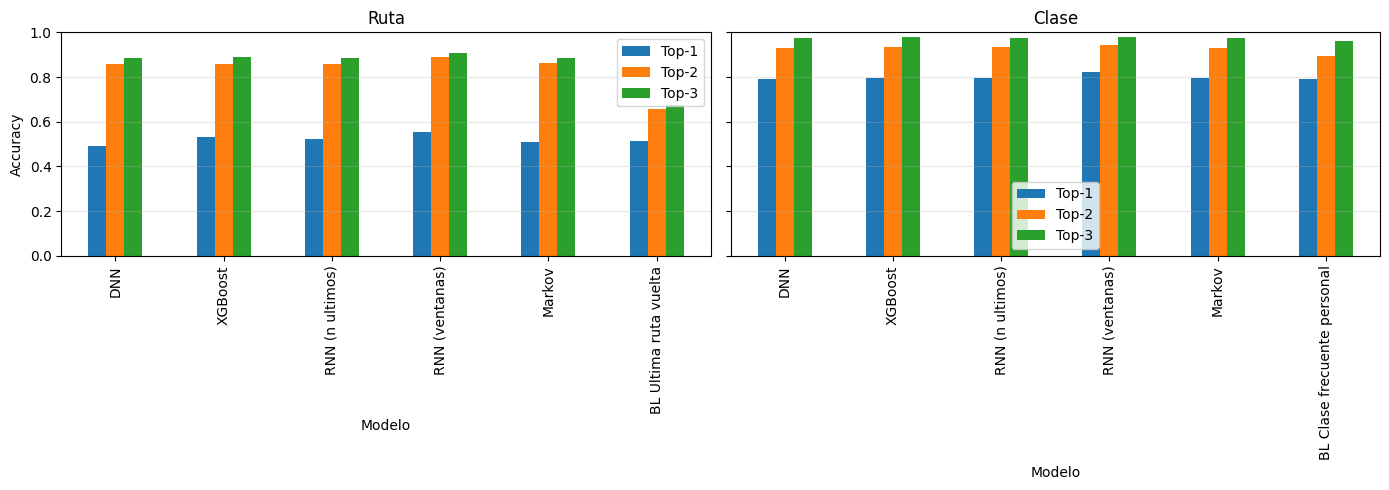

In [35]:
import matplotlib.pyplot as plt

def metrics_from_scores(y_true, scores):
    m = topk_metrics_from_scorer(y_true, scores, ks=(1,2,3))
    return {1: m[1], 2: m[2], 3: m[3]}


results = {}

# DNN
results["DNN"] = {
    "ruta": metrics_from_scores(y_ruta_test, logits_ruta),
    "clase": metrics_from_scores(y_clase_test, logits_clase),
}

# XGBoost
results["XGBoost"] = {
    "ruta": metrics_from_scores(y_ruta_test, proba_ruta),
    "clase": metrics_from_scores(y_clase_test, proba_clase),
}

# RNN
results["RNN (n ultimos)"] = metrics_rnn_lastn
results["RNN (ventanas)"] = metrics_rnn_sw

# Markov
results["Markov"] = {
    "ruta": {1: res_r[1], 2: res_r[2], 3: res_r[3]},
    "clase": {1: res_c[1], 2: res_c[2], 3: res_c[3]},
}

# Baselines (solo mejores)
if "baseline_results" in globals():
    results.update(baseline_results)


def plot_metrics(results, target, ax):
    rows = []
    for model, vals in results.items():
        if target not in vals:
            continue
        rows.append({
            "Modelo": model,
            "Top-1": vals[target][1],
            "Top-2": vals[target][2],
            "Top-3": vals[target][3],
        })

    df = pd.DataFrame(rows).set_index("Modelo")
    df.plot(kind="bar", ax=ax)
    ax.set_title(target.capitalize())
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.grid(axis="y", alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_metrics(results, "ruta", axes[0])
plot_metrics(results, "clase", axes[1])
plt.tight_layout()
# Guardamos archivo
fig.savefig("../figuras/resultados_finales.pdf")
plt.show()


In [36]:
# Valores de los resultados
print(results)

{'DNN': {'ruta': {1: 0.4921973850695909, 2: 0.859552931252636, 3: 0.8842260649514972}, 'clase': {1: 0.7931252636018558, 2: 0.9308308730493463, 3: 0.9765921552087726}}, 'XGBoost': {'ruta': {1: 0.5324757486292704, 2: 0.859552931252636, 3: 0.8916069169126951}, 'clase': {1: 0.793547026571067, 2: 0.9329396878954028, 3: 0.9774356811471953}}, 'RNN (n ultimos)': {'ruta': {1: 0.522986081822016, 2: 0.859552931252636, 3: 0.8861239983129481}, 'clase': {1: 0.7967102488401518, 2: 0.9327288064107971, 3: 0.9738506959088992}}, 'RNN (ventanas)': {'ruta': {1: 0.5555054558571557, 2: 0.8891694471999279, 3: 0.9077464153665795}, 'clase': {1: 0.8220759311028948, 2: 0.9433673009288485, 3: 0.9802506988907926}}, 'Markov': {'ruta': {1: 0.5111767186840995, 2: 0.8612399831294812, 3: 0.8871784057359764}, 'clase': {1: 0.7933361450864614, 2: 0.9301982285955294, 3: 0.975115984816533}}, 'BL Ultima ruta vuelta': {'ruta': {1: 0.5128637705609448, 2: 0.6560522986081821, 3: 0.6748207507380852}}, 'BL Clase frecuente personal'

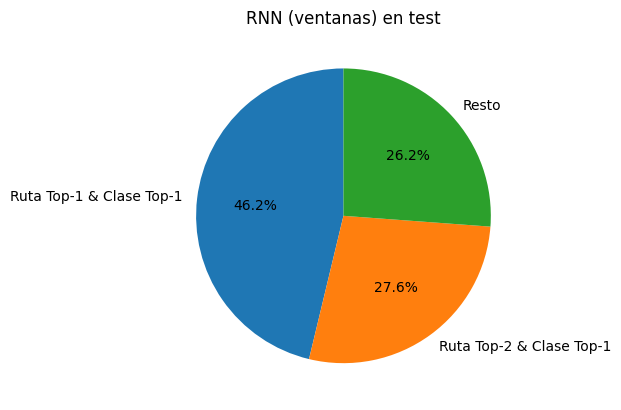

In [37]:
# Quesito RNN (ventanas): ruta top-1 / top-2 vs clase top-1
# Tensores de test
xr = torch.tensor(np.array(Xte_rutas), dtype=torch.float32).to(device)
xc = torch.tensor(np.array(Xte_clases), dtype=torch.float32).to(device)
xnum = torch.tensor(np.array(Xte_num), dtype=torch.float32).to(device)
xgap = torch.tensor(np.array(Xte_d_d_u_c), dtype=torch.float32).to(device)

with torch.no_grad():
    logits_r = ruta_model_sw(xr, xc, xnum, xgap)
    logits_c = clase_model_sw(xr, xc, xnum, xgap)

    top2_r = torch.topk(logits_r, k=2, dim=1).indices.cpu().numpy()
    top1_c = logits_c.argmax(dim=1).cpu().numpy()

    y_r = np.asarray(yte_r)
    y_c = np.asarray(yte_c)

    ruta_top1 = top2_r[:, 0] == y_r
    ruta_top2_only = (top2_r[:, 1] == y_r) & (~ruta_top1)
    clase_top1 = top1_c == y_c

    cat_a = ruta_top1 & clase_top1
    cat_b = ruta_top2_only & clase_top1
    cat_c = ~(cat_a | cat_b)

    counts = np.array([cat_a.sum(), cat_b.sum(), cat_c.sum()], dtype=int)
    labels = ["Ruta Top-1 & Clase Top-1", "Ruta Top-2 & Clase Top-1", "Resto"]

    plt.figure(figsize=(6, 6))
    plt.pie(counts, labels=labels, autopct="%1.1f%%", startangle=90)
    plt.title("RNN (ventanas) en test")
    plt.tight_layout()
    plt.show()
